In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time
import copy

# --- 1. DONANIM AYARI ---
# GPU varsa affetme, direkt kullan. Yoksa CPU ile devam (ama yavaş olur).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")
if device.type == 'cuda':
    print(f"Ekran Kartı: {torch.cuda.get_device_name(0)}")

# --- 2. VERİ YOLU VE AUGMENTATION (ÖNEMLİ) ---
DATA_DIR = r'C:\Users\user\Desktop\DerinProjem\garbage-dataset'

# ResNet'in eğitildiği standart istatistikler (ImageNet)
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Data Augmentation BURADA YAPILIYOR:
# Eğitim verisini zorlaştırıyoruz ki model ezberlemesin, gerçekten öğrensin.
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Resmin %80-%100'ünü rastgele al
    transforms.RandomHorizontalFlip(),      # Rastgele yatay çevir
    transforms.RandomRotation(15),          # 15 derece döndür
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Işık ve kontrastla hafif oyna
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Test/Validation setine dokunmuyoruz (Augmentation YOK), sadece boyutlandırıyoruz.
# Çünkü modelin gerçek performansını "oynanmamış" resimlerde görmeliyiz.
test_tfms = transforms.Compose([
    transforms.Resize((224, 224)), # Direkt resize (Crop yok)
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

Kullanılan Cihaz: cuda
Ekran Kartı: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# --- 3. DATASET VE SINIF AĞIRLIKLARI ---
# Train transformuyla yüklüyoruz ama aşağıda val/test için düzelteceğiz
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
classes = full_dataset.classes
print(f"\nSınıflar ({len(classes)} adet): {classes}")

# Sınıf sayımı (Hangi sınıftan kaç tane var?)
class_counts = {c: 0 for c in classes}
for _, label in full_dataset.samples:
    class_counts[classes[label]] += 1

print("\nVeri Seti Dağılımı:")
for c, count in class_counts.items():
    print(f"{c}: {count}")

# Ağırlık Hesabı: Az örneği olana yüksek puan (Ceza puanı gibi düşün)
total = sum(class_counts.values())
weights = [total / class_counts[c] for c in classes]
class_weights = torch.FloatTensor(weights).to(device)
print("\nHesaplanan Sınıf Ağırlıkları (Loss Fonksiyonu için):", [round(w, 2) for w in weights])

# --- 4. STRATIFIED SPLIT (DENGELİ BÖLME) ---
targets = [s[1] for s in full_dataset.samples]

# %70 Train, %30 Temp
train_idx, temp_idx = train_test_split(np.arange(len(full_dataset)), test_size=0.3, stratify=targets, random_state=42)
# %15 Val, %15 Test
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42)

# Subset oluşturma
train_ds = Subset(full_dataset, train_idx)
# DİKKAT: Val ve Test setleri için "test_tfms" (augmentationsız) kullanmak lazım.
# Subset içinde transform değiştirmek zor olduğu için bu datasetleri tekrar yüklüyoruz:
val_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tfms), val_idx)
test_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tfms), test_idx)

# Loader'lar
BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) # Windows'ta num_workers=0 önerilir
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nEğitim: {len(train_ds)}, Doğrulama: {len(val_ds)}, Test: {len(test_ds)}")


Sınıflar (10 adet): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

Veri Seti Dağılımı:
battery: 944
biological: 997
cardboard: 1825
clothes: 5327
glass: 3061
metal: 1020
paper: 1680
plastic: 1984
shoes: 1977
trash: 947

Hesaplanan Sınıf Ağırlıkları (Loss Fonksiyonu için): [20.93, 19.82, 10.83, 3.71, 6.46, 19.37, 11.76, 9.96, 10.0, 20.87]

Eğitim: 13833, Doğrulama: 2964, Test: 2965


In [3]:
# --- 5. MODELİ HAZIRLA ---
def get_resnet_model(num_classes):
    print("\nResNet18 indiriliyor ve modifiye ediliyor...")
    model = models.resnet18(pretrained=True)
    
    # Feature Extraction: Convolution katmanlarını dondur (Şimdilik ağırlıkları değişmesin)
    for param in model.parameters():
        param.requires_grad = False
    
    # Son katman (Classifier) değişimi
    num_ftrs = model.fc.in_features
    
    # Yeni kafa yapısı: Linear -> ReLU -> Dropout -> Linear
    # Bu katman "Açık" (requires_grad=True) olacak ve eğitilecek.
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.5), # %50 nöronu kapat, ezberi boz
        nn.Linear(512, num_classes)
    )
    return model.to(device)

model = get_resnet_model(len(classes))

# Loss ve Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights) # Ağırlıklı Loss!
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Sadece son katmanı eğit


ResNet18 indiriliyor ve modifiye ediliyor...


C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
# --- 6. EĞİTİM FONKSİYONU ---
def train_model(model, train_loader, val_loader, epochs=15):
    start_time = time.time()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 10)

        # -- TRAIN --
        model.train()
        running_loss = 0.0
        
        # Shape kontrolü için flag
        check_shape = True 

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # İSTENİLEN ÖZELLİK: Shape Kontrolü
            if check_shape and epoch == 0:
                print(f"[DEBUG] Input Shape (Batch): {inputs.shape}") 
                # Beklenen: [32, 3, 224, 224] -> 32 resim, 3 kanal (RGB), 224x224
                # print(f"[DEBUG] Label Shape: {labels.shape}")
                check_shape = False # Sadece ilkinde bas, sürekli basmasın

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # -- VALIDATION --
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total

        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

        # En iyi modeli kaydet
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'\nEğitim tamamlandı. Süre: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En iyi Val Acc: {best_acc:.4f}')
    
    # En iyi ağırlıkları yükle
    model.load_state_dict(best_model_wts)
    return model, history

# Eğitimi Başlat
trained_model, history = train_model(model, train_dl, val_dl, epochs=12) # Epoch sayısını değiştirebilirsin


Epoch 1/12
----------
[DEBUG] Input Shape (Batch): torch.Size([32, 3, 224, 224])
Train Loss: 0.8613 | Val Loss: 0.4118 | Val Acc: 0.8738

Epoch 2/12
----------
Train Loss: 0.5962 | Val Loss: 0.3913 | Val Acc: 0.8866

Epoch 3/12
----------
Train Loss: 0.5561 | Val Loss: 0.3299 | Val Acc: 0.8877

Epoch 4/12
----------
Train Loss: 0.5055 | Val Loss: 0.3843 | Val Acc: 0.8748

Epoch 5/12
----------
Train Loss: 0.5026 | Val Loss: 0.3377 | Val Acc: 0.8910

Epoch 6/12
----------
Train Loss: 0.4926 | Val Loss: 0.3063 | Val Acc: 0.9011

Epoch 7/12
----------
Train Loss: 0.4558 | Val Loss: 0.2978 | Val Acc: 0.9103

Epoch 8/12
----------
Train Loss: 0.4645 | Val Loss: 0.2928 | Val Acc: 0.9001

Epoch 9/12
----------
Train Loss: 0.4442 | Val Loss: 0.3057 | Val Acc: 0.9106

Epoch 10/12
----------
Train Loss: 0.4200 | Val Loss: 0.2631 | Val Acc: 0.9234

Epoch 11/12
----------
Train Loss: 0.4150 | Val Loss: 0.2693 | Val Acc: 0.9157

Epoch 12/12
----------
Train Loss: 0.4088 | Val Loss: 0.2817 | Val Ac


Test verileri üzerinde son değerlendirme yapılıyor...

MODEL PERFORMANS RAPORU (ResNet18 - FineTuned)
   Model      Class  Precision  Recall  F1-Score  Support
ResNet18    battery     0.8750  0.9433    0.9078    141.0
ResNet18 biological     0.9536  0.9664    0.9600    149.0
ResNet18  cardboard     0.9142  0.8942    0.9041    274.0
ResNet18    clothes     0.9886  0.9762    0.9824    799.0
ResNet18      glass     0.8914  0.8739    0.8825    460.0
ResNet18      metal     0.6748  0.9085    0.7744    153.0
ResNet18      paper     0.8560  0.8254    0.8404    252.0
ResNet18    plastic     0.8851  0.7752    0.8265    298.0
ResNet18      shoes     0.9467  0.9562    0.9514    297.0
ResNet18      trash     0.7917  0.8028    0.7972    142.0

[BİLGİ] Sonuçlar 'resnet18_results.csv' dosyasına kaydedildi.

Genel Accuracy: 0.9039


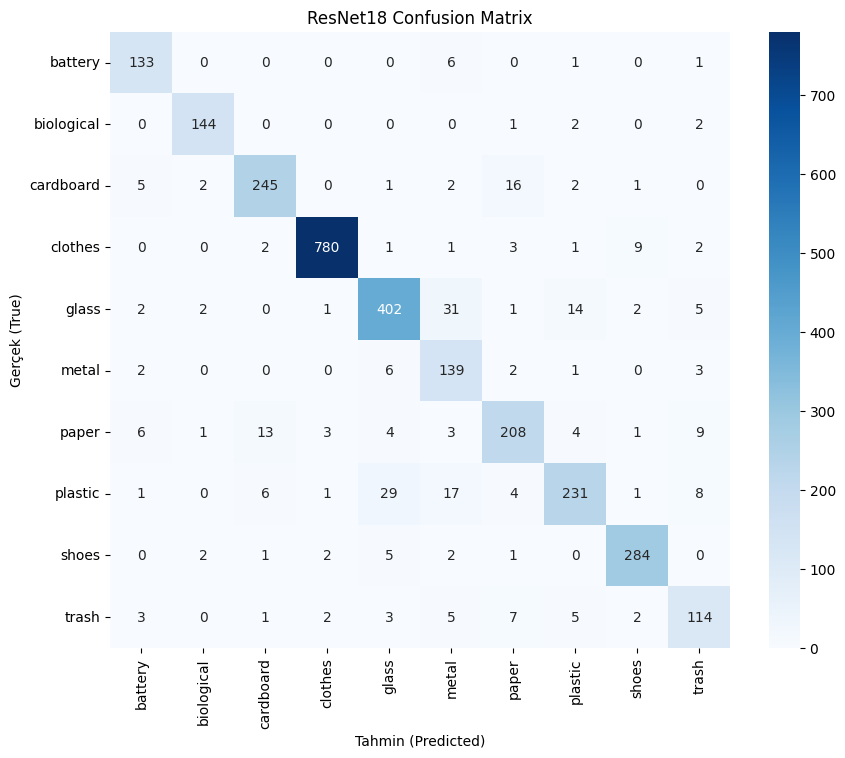

In [5]:
# --- 7. DETAYLI TEST RAPORU VE CSV ---
def evaluate_final(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    print("\nTest verileri üzerinde son değerlendirme yapılıyor...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    print("\n" + "="*50)
    print("MODEL PERFORMANS RAPORU (ResNet18 - FineTuned)")
    print("="*50)
    
    # dict formatında alıp pandas'a çevireceğiz
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    # Tabloyu oluştur
    results = []
    for cls in class_names:
        d = report_dict[cls]
        results.append({
            "Model": "ResNet18",
            "Class": cls,
            "Precision": d['precision'],
            "Recall": d['recall'],
            "F1-Score": d['f1-score'],
            "Support": d['support']
        })
    
    df_results = pd.DataFrame(results)
    
    # Ekrana düzgün bas
    print(df_results.round(4).to_string(index=False))
    
    # CSV Kaydet (Daha sonra AlexNet ile karşılaştırmak için lazım olacak)
    df_results.to_csv('resnet18_results.csv', index=False)
    print("\n[BİLGİ] Sonuçlar 'resnet18_results.csv' dosyasına kaydedildi.")

    # Genel Accuracy
    acc = report_dict['accuracy']
    print(f"\nGenel Accuracy: {acc:.4f}")

    return all_labels, all_preds

# Testi çalıştır
y_true, y_pred = evaluate_final(trained_model, test_dl, classes)

# --- 8. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('ResNet18 Confusion Matrix')
plt.xlabel('Tahmin (Predicted)')
plt.ylabel('Gerçek (True)')
plt.savefig('resnet18_confusion_matrix.png') # Resmi kaydet
plt.show()


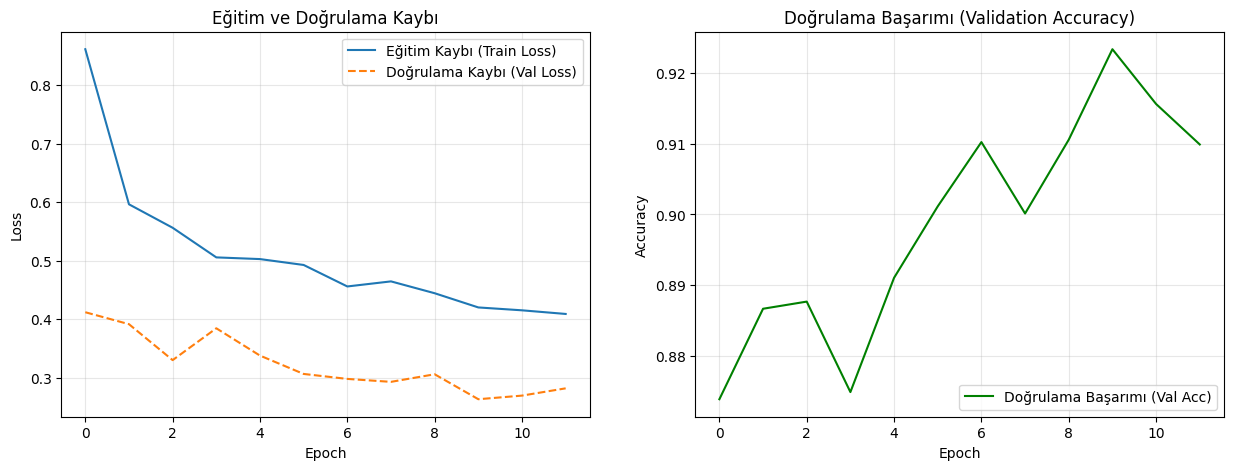

In [6]:
def plot_training_history(history):
    acc = history['train_loss'] 
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))
    
    # 1. Grafik: Loss (Hata) Değişimi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Eğitim Kaybı (Train Loss)')
    plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı (Val Loss)', linestyle="--")
    plt.legend(loc='upper right')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

    # 2. Grafik: Accuracy (Başarım) Değişimi
    plt.subplot(1, 2, 2)
    # Not: Train accuracy'yi history'de tutmadıysak sadece Val Acc çizeriz, o da yeterli.
    plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı (Val Acc)', color='green')
    plt.legend(loc='lower right')
    plt.title('Doğrulama Başarımı (Validation Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)

    plt.show()

# Fonksiyonu çağır (ResNet veya AlexNet history objesiyle)
# Not: Eğitim fonksiyonun 'history' döndürüyorsa çalışır.
# Eğer history değişkenin varsa:
plot_training_history(history)


--- Modelin Gözle Kontrolü ---


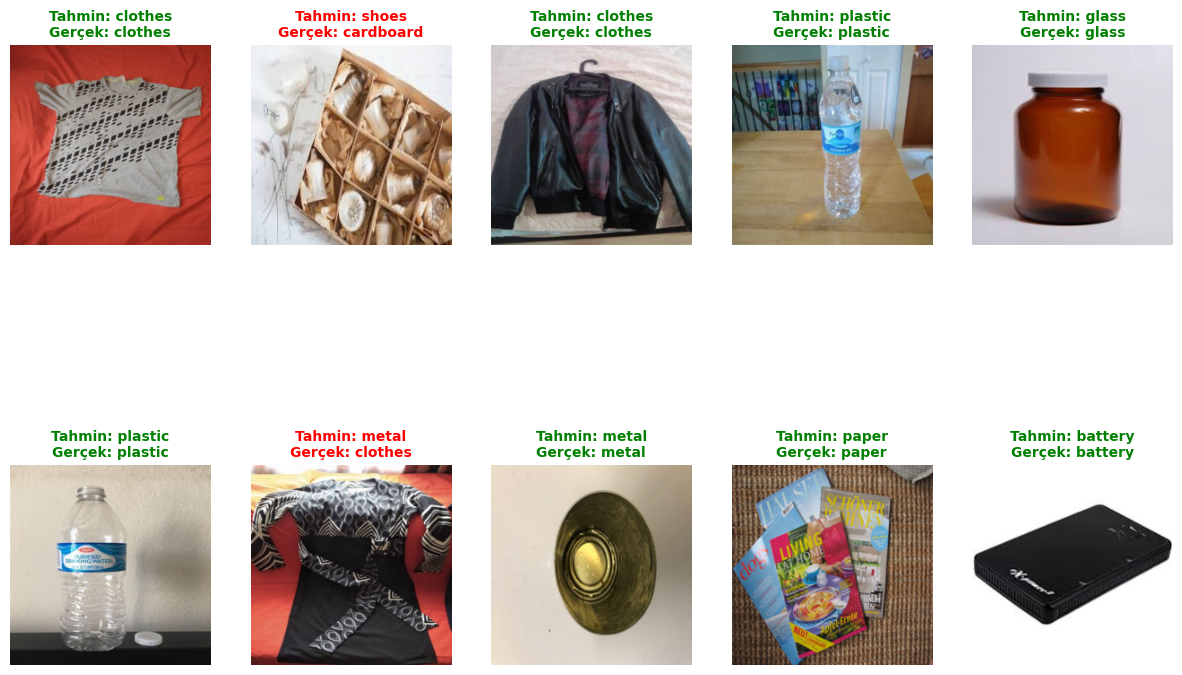

In [7]:
def visualize_model_predictions(model, loader, class_names, num_images=10):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))
    
    # Normalizasyonu geri almak için (Resimler düzgün görünsün diye)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(2, 5, images_so_far) # 2 satır 5 sütun
                ax.axis('off')
                
                # Resmi geri normalize et ve göster
                img = inputs.cpu().data[j]
                img = inv_normalize(img)
                img = np.transpose(img.numpy(), (1, 2, 0)) # (C,H,W) -> (H,W,C)
                img = np.clip(img, 0, 1) # Değerleri 0-1 arasına sıkıştır
                plt.imshow(img)
                
                # Başlık: Tahmin (Gerçek)
                predicted_label = class_names[preds[j]]
                true_label = class_names[labels[j]]
                
                color = 'green' if predicted_label == true_label else 'red'
                
                ax.set_title(f"Tahmin: {predicted_label}\nGerçek: {true_label}", 
                             color=color, fontsize=10, fontweight='bold')

                if images_so_far == num_images:
                    model.train()
                    return

# Kullanımı:
print("\n--- Modelin Gözle Kontrolü ---")
visualize_model_predictions(trained_model, test_dl, classes, num_images=10)

In [8]:
def evaluate_and_report_detailed(model, loader, class_names, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"\n[{model_name}] İçin Detaylı Rapor Hazırlanıyor...")
    
    # Tahminleri topla
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # --- 1. GENEL METRİKLER (Üst Kısım) ---
    # Scikit-learn raporu
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    print("\n" + "="*40)
    print(f"GENEL METRİKLER ({model_name})")
    print(f"Genel Accuracy: {report_dict['accuracy']:.4f}")
    print(f"Macro F1-Score: {report_dict['macro avg']['f1-score']:.4f}")
    print("="*40)

    # --- 2. SINIF BAZLI METRİKLER TABLOSU (Accuracy Sütunu Ekli) ---
    results = []
    for cls in class_names:
        metrics = report_dict[cls]
        
        # Referans görselindeki mantığa göre: Sınıf Bazlı Accuracy = Recall
        # (O sınıfa ait gerçek verilerin ne kadarını doğru bildik?)
        class_acc = metrics['recall'] 
        
        results.append({
            "Sınıf": cls,
            "Accuracy": class_acc,  # İstediğin Sınıf Bazlı Accuracy sütunu
            "Precision": metrics['precision'],
            "Recall": metrics['recall'],
            "F1-Score": metrics['f1-score']
        })
    
    # Pandas ile tabloyu oluştur
    df_results = pd.DataFrame(results)
    
    # Sütun sırasını görseldeki gibi yapalım
    df_results = df_results[["Sınıf", "Accuracy", "Precision", "Recall", "F1-Score"]]
    
    # Ekrana bas
    print("\nSINIF BAZLI METRİKLER:")
    print("-" * 65)
    print(df_results.round(4).to_string(index=False))
    print("-" * 65)
    
    # CSV Kaydet
    filename = f"{model_name}_Detailed_Results.csv"
    df_results.to_csv(filename, index=False)
    print(f"\nSonuçlar '{filename}' dosyasına kaydedildi.")
    
    return all_labels, all_preds

# --- KULLANIM ---
# ResNet için:
evaluate_and_report_detailed(trained_model, test_dl, classes, model_name="ResNet18")



[ResNet18] İçin Detaylı Rapor Hazırlanıyor...

GENEL METRİKLER (ResNet18)
Genel Accuracy: 0.9039
Macro F1-Score: 0.8827

SINIF BAZLI METRİKLER:
-----------------------------------------------------------------
     Sınıf  Accuracy  Precision  Recall  F1-Score
   battery    0.9433     0.8750  0.9433    0.9078
biological    0.9664     0.9536  0.9664    0.9600
 cardboard    0.8942     0.9142  0.8942    0.9041
   clothes    0.9762     0.9886  0.9762    0.9824
     glass    0.8739     0.8914  0.8739    0.8825
     metal    0.9085     0.6748  0.9085    0.7744
     paper    0.8254     0.8560  0.8254    0.8404
   plastic    0.7752     0.8851  0.7752    0.8265
     shoes    0.9562     0.9467  0.9562    0.9514
     trash    0.8028     0.7917  0.8028    0.7972
-----------------------------------------------------------------

Sonuçlar 'ResNet18_Detailed_Results.csv' dosyasına kaydedildi.


([np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(7),
  np.int64(4),
  np.int64(7),
  np.int64(3),
  np.int64(5),
  np.int64(6),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(8),
  np.int64(9),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(3),
  np.int64(2),
  np.int64(7),
  np.int64(3),
  np.int64(7),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(8),
  np.int64(7),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(7),
  np.int64(3),
  np.int64(0),
  np.int64(7),
  np.int64(3),
  np.int64(8),
  np.int64(4),
  np.int64(5),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(4),
  np.int64(3),
  np.int64(4),
  np.int64(6),
  np.int64(3),
  np.int64(0),
  np.int64(7),
  np.int64(3),
  np.int64(6),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(6),
  np.int64(5),
  np.int64(2),
  np.int64(3),
  np.int64(7),
  np.int64(7),
  np.int64

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import pandas as pd

def plot_all_metrics(model, loader, class_names, model_name="Model"):
    """
    Bu fonksiyon tek seferde Confusion Matrix, ROC, Precision-Recall ve F1 Skorlarını çizer.
    Tam teşekküllü bir raporlama aracıdır.
    """
    model.eval()
    
    y_true = []
    y_scores = [] # Olasılıklar (Softmax çıktıları)
    y_pred = []   # Kesin tahminler (0, 1, 2...)
    
    print(f"\n🚀 {model_name} İçin Tüm Grafikler Hazırlanıyor... (Biraz sürebilir)")
    
   
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            
            # Olasılıkları al (ROC ve PR için şart)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # Tahminleri al (Confusion Matrix için şart)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probs.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    y_pred = np.array(y_pred)
    
    # Veriyi Binarize Et (One-Hot Encoding - ROC/PR için gerekli)
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    plt.suptitle(f"{model_name} - Kapsamlı Performans Analizi", fontsize=20, fontweight='bold')
    
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    # ---------------------------------------------------------
    # 1. GRAFİK: CONFUSION MATRIX (Karmaşıklık Matrisi)
    # ---------------------------------------------------------
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0, 0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14)
    axes[0, 0].set_xlabel('Tahmin Edilen')
    axes[0, 0].set_ylabel('Gerçek Sınıf')

    # ---------------------------------------------------------
    # 2. GRAFİK: ROC CURVES (Alıcı İşletim Karakteristiği)
    # ---------------------------------------------------------
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0, 1].plot(fpr, tpr, color=color, lw=2,
                        label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2) # Şans çizgisi
    axes[0, 1].set_xlim([0.0, 1.0])
    axes[0, 1].set_ylim([0.0, 1.05])
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('ROC Eğrileri (One-vs-Rest)', fontsize=14)
    axes[0, 1].legend(loc="lower right")
    axes[0, 1].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 3. GRAFİK: PRECISION-RECALL CURVES (Hassasiyet-Duyarlılık)
    # ---------------------------------------------------------
   
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    for i, color in zip(range(n_classes), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
        avg_precision = average_precision_score(y_true_bin[:, i], y_scores[:, i])
        axes[1, 0].plot(recall, precision, color=color, lw=2,
                        label=f'{class_names[i]} (AP = {avg_precision:.2f})')
    
    axes[1, 0].set_xlabel('Recall (Duyarlılık)')
    axes[1, 0].set_ylabel('Precision (Hassasiyet/Kesinlik)')
    axes[1, 0].set_title('Precision-Recall Eğrileri', fontsize=14)
    axes[1, 0].legend(loc="lower left")
    axes[1, 0].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 4. GRAFİK: SINIF BAZLI F1 SKORLARI (Bar Chart)
    # ---------------------------------------------------------
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    f1_scores = [report[cls]['f1-score'] for cls in class_names]
    
  
    palette = sns.color_palette("viridis", len(class_names))
    bars = axes[1, 1].bar(class_names, f1_scores, color=palette)
    
    axes[1, 1].set_ylim([0, 1.0])
    axes[1, 1].set_title('Sınıf Bazlı F1-Score Başarımı', fontsize=14)
    axes[1, 1].set_ylabel('F1 Score')
    
    
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Başlık için yer aç
    plt.show()



if 'trained_alexnet' in locals():
    plot_all_metrics(trained_alexnet, test_dl, classes, model_name="AlexNet (Fine-Tuned)")



🚀 ResNet18 İçin Tüm Grafikler Hazırlanıyor... (Biraz sürebilir)


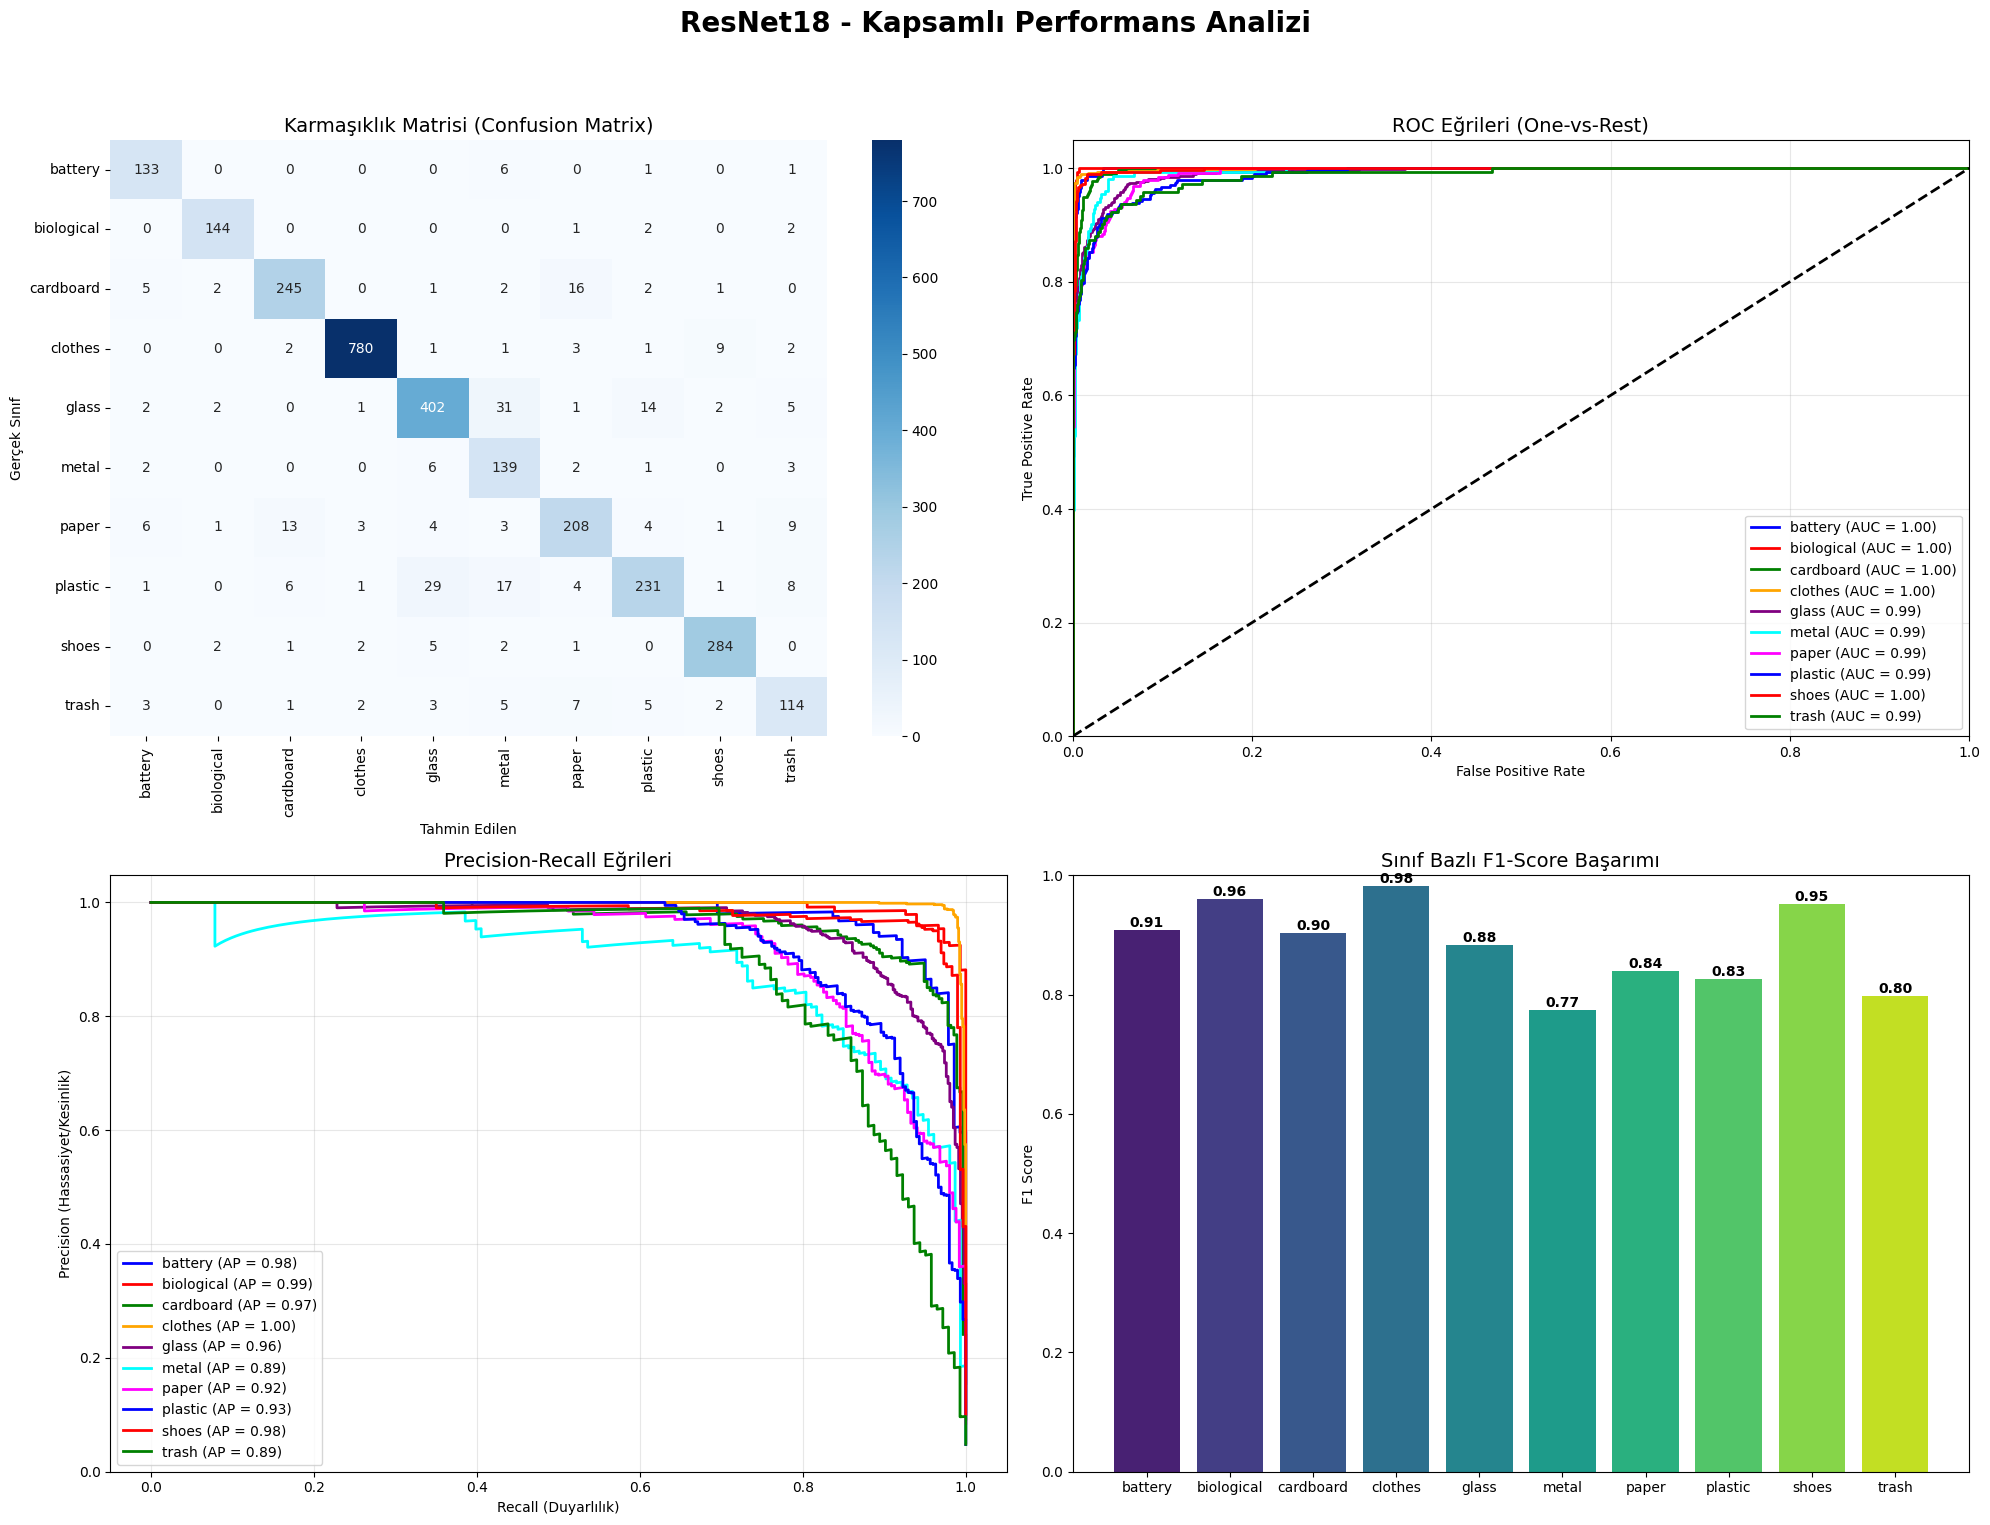

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import pandas as pd

def plot_all_metrics(model, loader, class_names, model_name="Model"):
    """
    Bu fonksiyon tek seferde Confusion Matrix, ROC, Precision-Recall ve F1 Skorlarını çizer.
    Tam teşekküllü bir raporlama aracıdır.
    """
    model.eval()
    
    y_true = []
    y_scores = [] # Olasılıklar (Softmax çıktıları)
    y_pred = []   # Kesin tahminler (0, 1, 2...)
    
    print(f"\n🚀 {model_name} İçin Tüm Grafikler Hazırlanıyor... (Biraz sürebilir)")
    
   
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            
            # Olasılıkları al (ROC ve PR için şart)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # Tahminleri al (Confusion Matrix için şart)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probs.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    y_pred = np.array(y_pred)
    
    # Veriyi Binarize Et (One-Hot Encoding - ROC/PR için gerekli)
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    plt.suptitle(f"{model_name} - Kapsamlı Performans Analizi", fontsize=20, fontweight='bold')
    
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    # ---------------------------------------------------------
    # 1. GRAFİK: CONFUSION MATRIX (Karmaşıklık Matrisi)
    # ---------------------------------------------------------
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0, 0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14)
    axes[0, 0].set_xlabel('Tahmin Edilen')
    axes[0, 0].set_ylabel('Gerçek Sınıf')

    # ---------------------------------------------------------
    # 2. GRAFİK: ROC CURVES (Alıcı İşletim Karakteristiği)
    # ---------------------------------------------------------
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0, 1].plot(fpr, tpr, color=color, lw=2,
                        label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2) # Şans çizgisi
    axes[0, 1].set_xlim([0.0, 1.0])
    axes[0, 1].set_ylim([0.0, 1.05])
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('ROC Eğrileri (One-vs-Rest)', fontsize=14)
    axes[0, 1].legend(loc="lower right")
    axes[0, 1].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 3. GRAFİK: PRECISION-RECALL CURVES (Hassasiyet-Duyarlılık)
    # ---------------------------------------------------------
   
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    for i, color in zip(range(n_classes), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
        avg_precision = average_precision_score(y_true_bin[:, i], y_scores[:, i])
        axes[1, 0].plot(recall, precision, color=color, lw=2,
                        label=f'{class_names[i]} (AP = {avg_precision:.2f})')
    
    axes[1, 0].set_xlabel('Recall (Duyarlılık)')
    axes[1, 0].set_ylabel('Precision (Hassasiyet/Kesinlik)')
    axes[1, 0].set_title('Precision-Recall Eğrileri', fontsize=14)
    axes[1, 0].legend(loc="lower left")
    axes[1, 0].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 4. GRAFİK: SINIF BAZLI F1 SKORLARI (Bar Chart)
    # ---------------------------------------------------------
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    f1_scores = [report[cls]['f1-score'] for cls in class_names]
    
  
    palette = sns.color_palette("viridis", len(class_names))
    bars = axes[1, 1].bar(class_names, f1_scores, color=palette)
    
    axes[1, 1].set_ylim([0, 1.0])
    axes[1, 1].set_title('Sınıf Bazlı F1-Score Başarımı', fontsize=14)
    axes[1, 1].set_ylabel('F1 Score')
    
    
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Başlık için yer aç
    plt.show()

if 'trained_model' in locals(): 
    plot_all_metrics(trained_model, test_dl, classes, model_name="ResNet18")

In [12]:
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = trained_model 
model.eval()

all_preds = []
all_labels = []

print("⏳ ResNet18 Genel Performansı Hesaplanıyor...")

with torch.no_grad():
    for inputs, labels in test_dl:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrikleri Hesapla
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

# Tabloyu Oluştur
df_resnet = pd.DataFrame([{
    "Model": "ResNet18",
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1-Score": round(f1, 4)
}])

print("\n" + "="*50)
print("📊 RESNET18 GENEL PERFORMANS TABLOSU")
print("="*50)
print(df_resnet.to_string(index=False))
print("="*50)

⏳ ResNet18 Genel Performansı Hesaplanıyor...

📊 RESNET18 GENEL PERFORMANS TABLOSU
   Model  Accuracy  Precision  Recall  F1-Score
ResNet18    0.9039      0.908  0.9039    0.9045



🚀 ResNet18 İÇİN KAPSAMLI ANALİZ BAŞLIYOR...

📊 ResNet18 - SINIF BAZLI DOĞRULUK (ACCURACY) TABLOSU
--------------------------------------------------
     Sınıf  Accuracy
   battery    0.9433
biological    0.9664
 cardboard    0.8942
   clothes    0.9762
     glass    0.8739
     metal    0.9085
     paper    0.8254
   plastic    0.7752
     shoes    0.9562
     trash    0.8028


🎯 ResNet18 - SINIF BAZLI HASSASİYET (PRECISION) TABLOSU
--------------------------------------------------
     Sınıf  Precision
   battery     0.8750
biological     0.9536
 cardboard     0.9142
   clothes     0.9886
     glass     0.8914
     metal     0.6748
     paper     0.8560
   plastic     0.8851
     shoes     0.9467
     trash     0.7917


📢 ResNet18 - SINIF BAZLI DUYARLILIK (RECALL) TABLOSU
--------------------------------------------------
     Sınıf  Recall
   battery  0.9433
biological  0.9664
 cardboard  0.8942
   clothes  0.9762
     glass  0.8739
     metal  0.9085
     paper  0.8254
   plastic

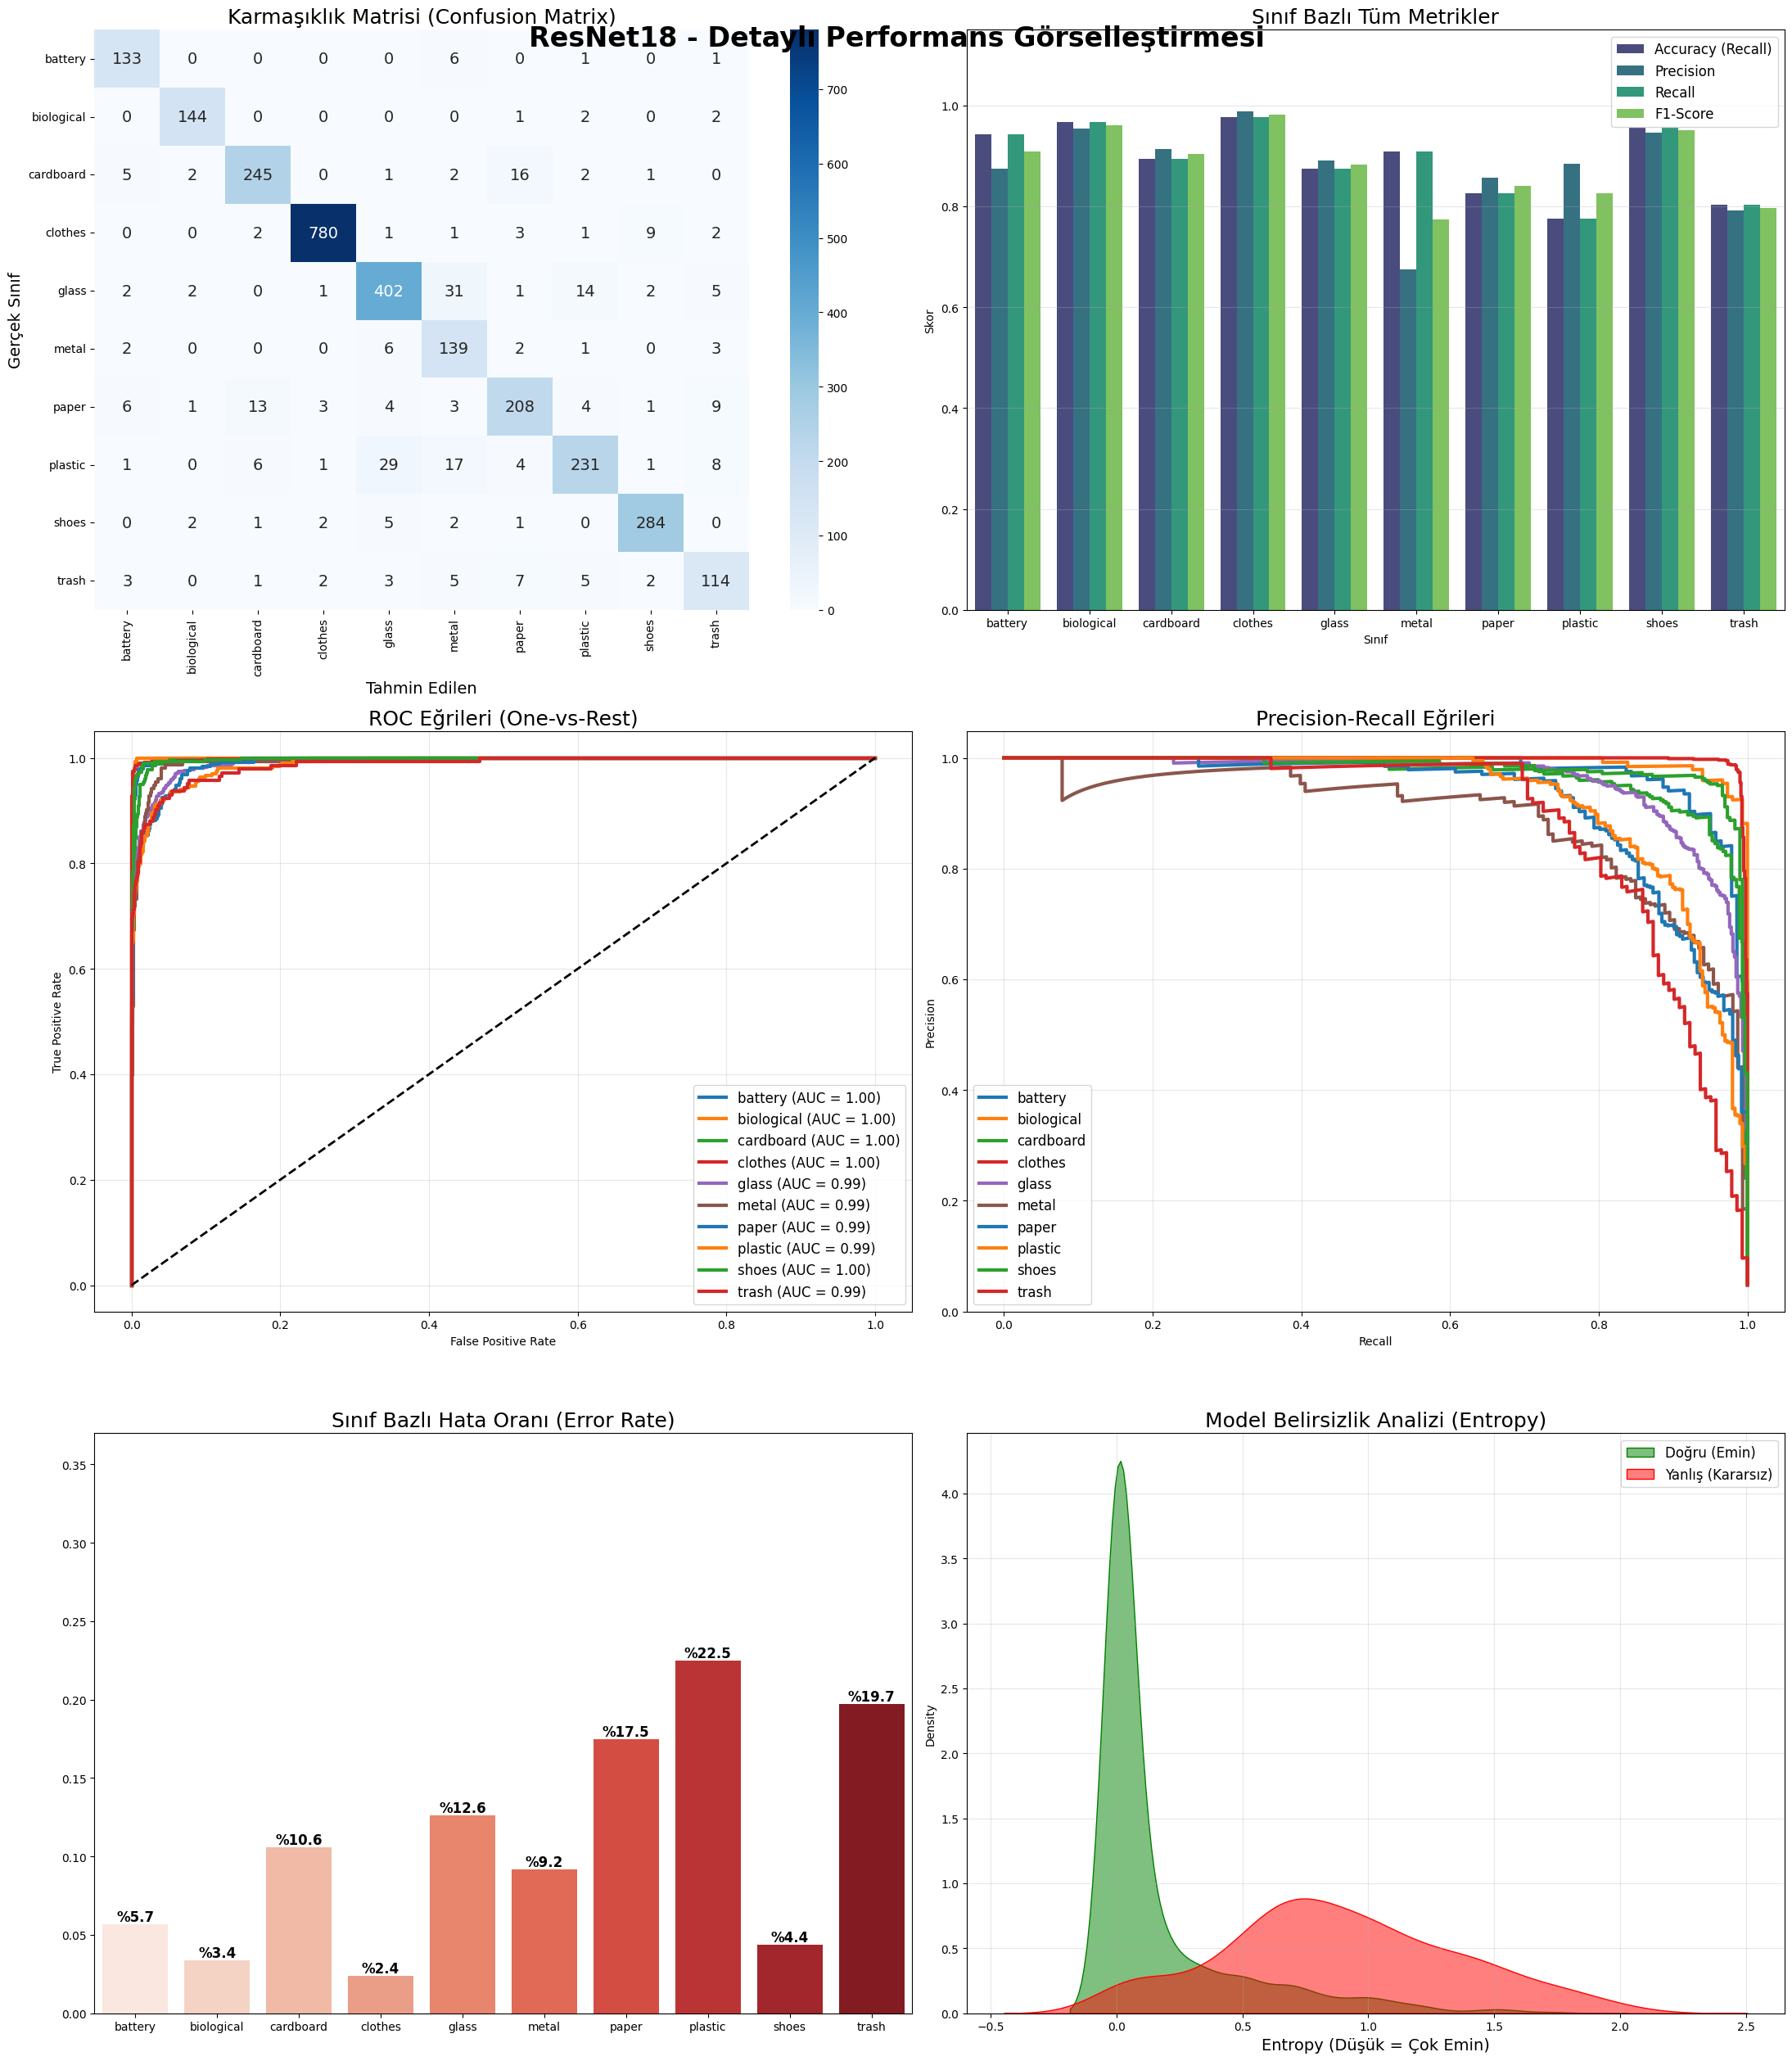


✅ Tüm işlemler tamamlandı! Grafikler 'ResNet18_Ultimate_Report.png' dosyasına kaydedildi.


In [14]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
from itertools import cycle
import warnings

# Uyarıları kapat (Temiz çıktı için)
warnings.filterwarnings('ignore')

def thesis_full_analysis(model, loader, class_names, model_name="Model"):
    """
    Bu fonksiyon:
    1. Her metrik (Acc, Prec, Rec, F1) için AYRI AYRI tablo basar.
    2. Tez/Rapor kalitesinde 6 farklı grafik çizer.
    """
    print(f"\n🚀 {model_name} İÇİN KAPSAMLI ANALİZ BAŞLIYOR...\n")
    
    # --- 1. Cihaz ve Veri Hazırlığı ---
    try:
        device = next(model.parameters()).device
    except:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    model.eval()
    model.to(device)
    
    y_true = []
    y_pred = []
    y_probs = []
    y_entropy = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            # Entropy (Belirsizlik)
            entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)
            
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            y_entropy.extend(entropy.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    y_entropy = np.array(y_entropy)
    
    # --- 2. AYRI AYRI TABLOLARIN OLUŞTURULMASI ---
    
    # Scikit-learn raporunu al
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Verileri çek
    data = {
        "Sınıf": class_names,
        "Accuracy (Recall)": [report[c]['recall'] for c in class_names], # Sınıf bazlı accuracy = Recall
        "Precision": [report[c]['precision'] for c in class_names],
        "Recall": [report[c]['recall'] for c in class_names],
        "F1-Score": [report[c]['f1-score'] for c in class_names]
    }
    
    # TABLO 1: SINIF BAZLI ACCURACY TABLOSU
    df_acc = pd.DataFrame({"Sınıf": data["Sınıf"], "Accuracy": data["Accuracy (Recall)"]})
    print(f"📊 {model_name} - SINIF BAZLI DOĞRULUK (ACCURACY) TABLOSU")
    print("-" * 50)
    print(df_acc.round(4).to_string(index=False))
    print("\n")

    # TABLO 2: SINIF BAZLI PRECISION TABLOSU
    df_prec = pd.DataFrame({"Sınıf": data["Sınıf"], "Precision": data["Precision"]})
    print(f"🎯 {model_name} - SINIF BAZLI HASSASİYET (PRECISION) TABLOSU")
    print("-" * 50)
    print(df_prec.round(4).to_string(index=False))
    print("\n")

    # TABLO 3: SINIF BAZLI RECALL TABLOSU
    df_rec = pd.DataFrame({"Sınıf": data["Sınıf"], "Recall": data["Recall"]})
    print(f"📢 {model_name} - SINIF BAZLI DUYARLILIK (RECALL) TABLOSU")
    print("-" * 50)
    print(df_rec.round(4).to_string(index=False))
    print("\n")

    # TABLO 4: SINIF BAZLI F1-SCORE TABLOSU
    df_f1 = pd.DataFrame({"Sınıf": data["Sınıf"], "F1-Score": data["F1-Score"]})
    print(f"⚖️ {model_name} - SINIF BAZLI F1 SKORU TABLOSU")
    print("-" * 50)
    print(df_f1.round(4).to_string(index=False))
    print("\n" + "="*60 + "\n")
    
    # Tabloları Kaydet (CSV)
    df_acc.to_csv(f"{model_name}_Table_Accuracy.csv", index=False)
    df_prec.to_csv(f"{model_name}_Table_Precision.csv", index=False)
    df_rec.to_csv(f"{model_name}_Table_Recall.csv", index=False)
    df_f1.to_csv(f"{model_name}_Table_F1.csv", index=False)

    # --- 3. EKSİKSİZ VE DÜZGÜN GRAFİKLER ---
    
    # Grafik Alanı: 3 Satır x 2 Sütun (Büyük Boyut)
    fig, axes = plt.subplots(3, 2, figsize=(22, 28))
    plt.suptitle(f"{model_name} - Detaylı Performans Görselleştirmesi", fontsize=24, fontweight='bold', y=0.92)
    
    # Renk Paletleri
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
    
    # --- G1: CONFUSION MATRIX ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
    axes[0, 0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=18)
    axes[0, 0].set_xlabel('Tahmin Edilen', fontsize=14)
    axes[0, 0].set_ylabel('Gerçek Sınıf', fontsize=14)

    # --- G2: SINIF BAZLI METRİKLER (GRUP BAR) ---
    # Accuracy, Precision, Recall, F1 yan yana
    df_full = pd.DataFrame(data)
    df_melt = df_full.melt(id_vars="Sınıf", var_name="Metrik", value_name="Skor")
    
    sns.barplot(x="Sınıf", y="Skor", hue="Metrik", data=df_melt, ax=axes[0, 1], palette="viridis")
    axes[0, 1].set_title('Sınıf Bazlı Tüm Metrikler', fontsize=18)
    axes[0, 1].set_ylim(0, 1.15)
    axes[0, 1].legend(loc='upper right', fontsize=12)
    axes[0, 1].grid(axis='y', alpha=0.3)

    # --- G3: ROC EĞRİLERİ ---
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1, 0].plot(fpr, tpr, color=color, lw=3, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[1, 0].set_title('ROC Eğrileri (One-vs-Rest)', fontsize=18)
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(loc="lower right", fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    # --- G4: PRECISION-RECALL EĞRİLERİ ---
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
    for i, color in zip(range(len(class_names)), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        axes[1, 1].plot(recall, precision, color=color, lw=3, label=f'{class_names[i]}')
        
    axes[1, 1].set_title('Precision-Recall Eğrileri', fontsize=18)
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend(loc="lower left", fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

    # --- G5: ERROR RATE (HATA ORANI) ---
    error_rates = [1 - r for r in data["Recall"]]
    sns.barplot(x=class_names, y=error_rates, ax=axes[2, 0], palette="Reds")
    axes[2, 0].set_title('Sınıf Bazlı Hata Oranı (Error Rate)', fontsize=18)
    axes[2, 0].set_ylim(0, max(error_rates) * 1.2 + 0.1)
    # Değerleri yaz
    for p in axes[2, 0].patches:
        axes[2, 0].annotate(f'%{p.get_height()*100:.1f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=12, fontweight='bold')

    # --- G6: PREDICTION ENTROPY (BELİRSİZLİK) ---
    correct_mask = y_true == y_pred
    sns.kdeplot(y_entropy[correct_mask], fill=True, color='green', label='Doğru (Emin)', ax=axes[2, 1], alpha=0.5)
    sns.kdeplot(y_entropy[~correct_mask], fill=True, color='red', label='Yanlış (Kararsız)', ax=axes[2, 1], alpha=0.5)
    axes[2, 1].set_title('Model Belirsizlik Analizi (Entropy)', fontsize=18)
    axes[2, 1].set_xlabel('Entropy (Düşük = Çok Emin)', fontsize=14)
    axes[2, 1].legend(fontsize=12)
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"{model_name}_Ultimate_Report.png")
    plt.show()
    print(f"\n✅ Tüm işlemler tamamlandı! Grafikler '{model_name}_Ultimate_Report.png' dosyasına kaydedildi.")


if 'trained_model' in globals():
    thesis_full_analysis(trained_model, test_dl, classes, model_name="ResNet18")
if 'trained_resnet' in globals():
    thesis_full_analysis(trained_resnet, test_dl, classes, model_name="ResNet18")
